<a href="https://colab.research.google.com/github/iv23995-ctrl/CI345_ML/blob/main/Lab11_DT_SVM_for_weather.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Lab10 - Decision Tree for Weather

# Step 1 : Loading Data


In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [57]:
from google.colab import drive

#Mount Google Drive
drive.mount('/content/drive')

# Path to your CSV in Drive
weather_file = '/content/drive/MyDrive/CI345_ML/data/Weather.csv'

weather_table = pd.read_csv(weather_file)
weather_table.head(2)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,Day,Outlook,Temp,Humidity,Wind,PlayTennis
0,D1,Sunny,Hot,High,Weak,No
1,D2,Sunny,Hot,High,Strong,No


# Step 2 : Basic Data Analysis

In [58]:
df = weather_table.copy()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14 entries, 0 to 13
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Day         14 non-null     object
 1   Outlook     14 non-null     object
 2   Temp        14 non-null     object
 3   Humidity    14 non-null     object
 4   Wind        14 non-null     object
 5   PlayTennis  14 non-null     object
dtypes: object(6)
memory usage: 804.0+ bytes


In [59]:
df.columns

Index(['Day', 'Outlook', 'Temp', 'Humidity', 'Wind', 'PlayTennis'], dtype='object')

In [60]:
df.shape
df.head(14)

,Day,Outlook,Temp,Humidity,Wind,PlayTennis
0,D1,Sunny,Hot,High,Weak,No
1,D2,Sunny,Hot,High,Strong,No
2,D3,Overcast,Hot,High,Weak,Yes
3,D4,Rain,Mild,High,Weak,Yes
4,D5,Rain,Cool,Normal,Weak,Yes
5,D6,Rain,Cool,Normal,Strong,No
6,D7,Overcast,Cool,Normal,Weak,Yes
7,D8,Sunny,Mild,High,Weak,No
8,D9,Sunny,Cold,Normal,Weak,Yes
9,D10,Rain,Mild,Normal,Strong,Yes


In [61]:
df.isnull().sum()

,0
Day,0
Outlook,0
Temp,0
Humidity,0
Wind,0
PlayTennis,0


# Step 3: Data Visualization

<Axes: xlabel='PlayTennis'>

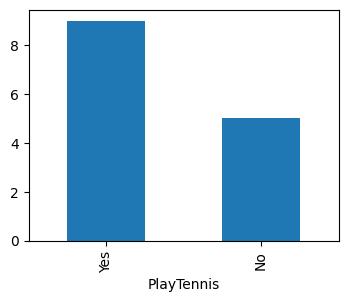

In [62]:
res = df.PlayTennis.value_counts()
res.plot(kind ='bar', figsize=(4,3))

# Step 4: Processing Data

In [63]:
df = weather_table.copy()
# Method 1:  Use LabelEncoder
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['Humidity'] = le.fit_transform(df['Humidity'])
df['Wind'] = le.fit_transform(df['Wind'])
df.head(1)

,Day,Outlook,Temp,Humidity,Wind,PlayTennis
0,D1,Sunny,Hot,0,1,No


In [64]:
print(df.Outlook.unique())
print(df.Temp.unique())

['Sunny' 'Overcast' 'Rain']
['Hot' 'Mild' 'Cool' 'Cold']


In [65]:
# Method 2:  Use mapping method
Outlook_mapping = {'Sunny':0, 'Overcast':1, 'Rain':2}
Temp_mapping = {'Hot':0, 'Mild':1, 'Cool':2, 'Cold':3}

df['Outlook'] = df['Outlook'].map(Outlook_mapping)
#df['PlayTennis'] = df['PlayTennis'].map({'No':0, 'Yes':1})
df['Temp'] = df['Temp'].map(Temp_mapping)

In [66]:
df.head(14)

,Day,Outlook,Temp,Humidity,Wind,PlayTennis
0,D1,0,0,0,1,No
1,D2,0,0,0,0,No
2,D3,1,0,0,1,Yes
3,D4,2,1,0,1,Yes
4,D5,2,2,1,1,Yes
5,D6,2,2,1,0,No
6,D7,1,2,1,1,Yes
7,D8,0,1,0,1,No
8,D9,0,3,1,1,Yes
9,D10,2,1,1,0,Yes


# Step 5: Get data and target

In [67]:
data = df[['Outlook','Temp','Humidity','Wind']]
target = df['PlayTennis']
data.head(2)
target.head(2)

,PlayTennis
0,No
1,No


#Step 6 : Classification by DT

In [68]:
# Step : Split Dataset
from sklearn.model_selection import train_test_split

data_train, data_test, target_train, target_test  = \
       train_test_split (data, target, random_state = 13, test_size = 0.4)

# What is the output
print(data_train.shape)
print(data_test.shape)

print(target_train.shape)
print(target_test.shape)

(8, 4)
(6, 4)
(8,)
(6,)


In [69]:
# Step 4: Create a decision tree
from sklearn import tree
dt_classifier = tree.DecisionTreeClassifier(max_depth=4)

#Training the decision classifier
dt_classifier.fit (X = data_train, y = target_train)
print(dt_classifier)

# Step 5: Testing
predicted = dt_classifier.predict(X= data_test)

# Step 6: Evaluation, Classification report
from sklearn.metrics import classification_report
report = classification_report(target_test, predicted)
print(report)

#Use Confusion_matrix
from sklearn.metrics import confusion_matrix
matrix = confusion_matrix(y_true = target_test, y_pred = predicted)
print('------ Confusion Matrix')
print(matrix)

DecisionTreeClassifier(max_depth=4)
              precision    recall  f1-score   support

          No       0.33      0.50      0.40         2
         Yes       0.67      0.50      0.57         4

    accuracy                           0.50         6
   macro avg       0.50      0.50      0.49         6
weighted avg       0.56      0.50      0.51         6

------ Confusion Matrix
[[1 1]
 [2 2]]


In [70]:
print(data_train[:3])
print(data_test[:3])
print(target_train[:3])
print(target_test[:3])

    Outlook  Temp  Humidity  Wind
1         0     0         0     0
4         2     2         1     1
13        2     1         0     0
    Outlook  Temp  Humidity  Wind
9         2     1         1     0
11        1     1         0     0
5         2     2         1     0
1      No
4     Yes
13     No
Name: PlayTennis, dtype: object
9     Yes
11    Yes
5      No
Name: PlayTennis, dtype: object


In [71]:
print(data_train.shape)
print(data_test.shape)

print(target_train.shape)
print(target_test.shape)

(8, 4)
(6, 4)
(8,)
(6,)


In [74]:
from sklearn.svm import SVC
from sklearn.metrics import classification_report

#Create svm Classifier
svm_classifier = SVC(kernel='poly')
#Train the model using the training sets
svm_classifier.fit(X=data_train, y=target_train)

#Predict the response for test dataset
predicted = svm_classifier.predict(X=data_test)
report = classification_report(target_test, predicted)
print(report)

from sklearn.metrics import confusion_matrix
matrix = confusion_matrix(y_true = target_test, y_pred = predicted)
print('------ Confusion Matrix')
print(matrix)
print("---")
print(predicted)
actual = target_test.values
print(actual)

              precision    recall  f1-score   support

          No       0.50      0.50      0.50         2
         Yes       0.75      0.75      0.75         4

    accuracy                           0.67         6
   macro avg       0.62      0.62      0.62         6
weighted avg       0.67      0.67      0.67         6

------ Confusion Matrix
[[1 1]
 [1 3]]
---
['Yes' 'No' 'Yes' 'Yes' 'Yes' 'No']
['Yes' 'Yes' 'No' 'Yes' 'Yes' 'No']
